## 1. What this notebook computes

This notebook is about REAL fields: columns of 16 components that are their own
complex conjugates. They matter for two reasons. The author's own notebook wrote its
Lagrangian for a real column; and the question "what is charge conjugation?" has a
surprising answer for real fields. The notebook

- computes, in the author's metric, the Majorana-type Lagrangian $L_g = \sqrt{|g|}\,
  \Theta^T C\gamma^\mu D_\mu\Theta$ of the author's notebook for a real column
  $\Theta$ of anticommuting (Grassmann) components and shows that it is a total
  derivative: all 16 Euler-Lagrange expressions vanish, there is no field equation;
- shows that for real COMMUTING components the same $L_g$ is not a total
  derivative: it gives a field equation in all 16 components;
- shows that the Revision Lagrangian restricted to a real commuting field gives the
  field equation $\gamma^\mu D_\mu\Phi = (m + \lambda S)\Phi$ and that its conserved
  current vanishes identically;
- finds ALL matrices $M$ that turn solutions $\Psi$ into solutions $M\Psi^*$: only
  multiples of the identity (same mass) and of the chirality matrix $\Gamma$ (mass
  reversed). Hence the two charge-conjugation matrices are $\mathcal{C}_+ = C$ and
  $\mathcal{C}_- = \Gamma C$;
- shows that for a real field plain complex conjugation, and with it
  $\mathcal{C}_+$, acts as the identity, so it cannot exchange matter and
  antimatter, while the real matrix $\Gamma$ maps every real solution of mass $m$ to
  a real solution of mass $-m$.

Every result that the Revision record also contains is checked against it
(Revision/theory/reports/ and Revision/lead_checks/reports/). Four figures are
drawn.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 07c (Real fields: the Majorana-type control and the matrix Gamma) is the file
`Revision/textbook/notebooks/07c_real_fields.ipynb` of the repository Dirac_claude. It
shows in the author's metric, with exact computer algebra, that the Majorana-type
Lagrangian of the author's notebook is a total derivative with no field equation for a
real anticommuting 16-component field but not for real commuting components; that for a
real field plain complex conjugation is the identity and the conserved current vanishes;
that every matrix that maps solutions to solutions in the conjugated form is a multiple
of the identity (same mass) or of the chirality matrix Gamma (mass reversed), which gives
the two charge-conjugation matrices C and Gamma C; and that the real matrix Gamma maps
every real solution of mass m to a real solution of mass minus m; four teaching plots. It
needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy and
matplotlib; the other packages run Jupyter, the program that shows and runs notebooks. It
does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 07c_real_fields.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 07c_real_fields.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
07c_real_fields.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/07c.captions.json`
- `Revision/textbook/figures/07c_1_majorana_control.png`
- `Revision/textbook/figures/07c_2_commutation_pattern.png`
- `Revision/textbook/figures/07c_3_gamma_map_matrices.png`
- `Revision/textbook/figures/07c_4_mass_reversal.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 4 figure files of this notebook exist
    ALL 23 CHECKS PASSED (notebook 07c)

and the notebook must show 4 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/07c_real_fields.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "ValueError: ... is not a passing check of Revision/...": the Revision record files of
  your copy of the repository differ from the committed ones; restore them with the
  command below (run in the repository folder) and run the notebook again.

      git restore Revision/theory Revision/algebra Revision/lead_checks

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 07c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 07c (Real fields: the Majorana-type control and the matrix Gamma) is the file
# Revision/textbook/notebooks/07c_real_fields.ipynb of the repository Dirac_claude. It
# shows in the author's metric, with exact computer algebra, that the Majorana-type
# Lagrangian of the author's notebook is a total derivative with no field equation for a
# real anticommuting 16-component field but not for real commuting components; that for a
# real field plain complex conjugation is the identity and the conserved current
# vanishes; that every matrix that maps solutions to solutions in the conjugated form is
# a multiple of the identity (same mass) or of the chirality matrix Gamma (mass
# reversed), which gives the two charge-conjugation matrices C and Gamma C; and that the
# real matrix Gamma maps every real solution of mass m to a real solution of mass minus
# m; four teaching plots. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 07c_real_fields.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 07c_real_fields.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 07c_real_fields.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/07c.captions.json
# - Revision/textbook/figures/07c_1_majorana_control.png
# - Revision/textbook/figures/07c_2_commutation_pattern.png
# - Revision/textbook/figures/07c_3_gamma_map_matrices.png
# - Revision/textbook/figures/07c_4_mass_reversal.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 4 figure files of this notebook exist
#     ALL 23 CHECKS PASSED (notebook 07c)
#
# and the notebook must show 4 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/07c_real_fields.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "ValueError: ... is not a passing check of Revision/...": the Revision record files
#   of your copy of the repository differ from the committed ones; restore them with the
#   command below (run in the repository folder) and run the notebook again.
#     git restore Revision/theory Revision/algebra Revision/lead_checks
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "07c"  # this notebook: chapter 07, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 07c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Real field**: a column $\Phi$ whose 16 components are real ($\Phi^* = \Phi$);
  for Grassmann components, a column of real generators ($\theta^* = \theta$).
- **Complex conjugation**: replacing every number by its complex conjugate
  ($i \to -i$). On a real column it changes nothing: it is the identity.
- **Charge conjugation**: a map that turns a field into a field of the opposite
  charge. For a spinor field it is a MATRIX map $\Psi^c = \mathcal{C}\,
  \bar\Psi^T$ with a fixed $16\times16$ matrix $\mathcal{C}$, the
  **charge-conjugation matrix**; since $\bar\Psi^T = (\Psi^\dagger C)^T =
  C\Psi^*$, it is $\Psi^c = \mathcal{C}C\,\Psi^*$.
- **Chirality matrix** $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$:
  the product of all eight gammas; it anticommutes with every $\gamma^{(a)}$ and
  $\Gamma^2 = 1$.
- **Majorana (reality) condition**: a condition $\Psi = M\Psi^*$ that makes a
  field real in a generalised sense; it is consistent only if $MM^* = 1$.
- **Majorana-type Lagrangian** $L_g$: the Lagrangian of the author's notebook, built
  with the transpose $\Theta^T$ of a real column instead of the Dirac adjoint
  $\bar\Psi = \Psi^\dagger C$.
- **Total derivative**: an expression $\sum_\mu \frac{d}{dx_\mu}V^\mu$; a Lagrangian
  that is a total derivative gives no field equation (its Euler-Lagrange expressions
  vanish identically).
- **Negative control**: a test designed to show that something does NOT work, here
  the Majorana-type Lagrangian; it explains why the Revision record uses the complex
  Dirac-type Lagrangian.
- **Current** $J^a = -i\bar\Psi\gamma^{(a)}\Psi$: the conserved current of the
  phase symmetry $\Psi \to e^{i\alpha}\Psi$; its time component gives the charge.
- **Commute, anticommute**: $XY = YX$ or $XY = -YX$ for two matrices.
- **Jet**, **total derivative on jets**, **coefficient ring**: as in Notebook 07b:
  the field components and their derivatives at one point are symbols, and every
  coefficient is written with $E = e^{a_4}$, $s = \sin^{1/6}z$, $c = \cos z$,
  $A_1 = a_4'$, $A_2$, $A_3$ (higher derivatives of $a_4$), $H$, $m$, $\lambda$.

## 4. The physical and mathematical situation

**The author's Lagrangian.** The author's notebook used a real column of 16
components and the Lagrangian $L_g = \sqrt{|g|}\,[\Theta^T C\gamma^\mu D_\mu\Theta +
(\text{number})\,\Theta^T C\Theta]$. If the components anticommute, as the
components of a fermion field must, then $\Theta^T C\Theta = 0$ because $C$ is
symmetric, and $\Theta^T C\gamma^\mu D_\mu\Theta$ is a total derivative because
$C\gamma^{(a)}$ is antisymmetric (Notebook 07a showed both rules in small form). So
$L_g$ describes nothing: this is the negative control of the Revision record, and
the reason why the Revision Lagrangian uses the complex field and $\bar\Psi =
\Psi^\dagger C$.

**Charge conjugation is a matrix.** The author's gammas are real. For a REAL
field, $\Psi^* = \Psi$, so plain complex conjugation changes nothing and cannot be
charge conjugation. Charge conjugation is the matrix map
$\Psi^c = \mathcal{C}C\,\Psi^*$, which must send every solution of $(\gamma^\mu
D_\mu - V)\Psi = 0$ ($V = m + U'(S)$, real) to a solution of the equation with $sV$,
where $s = +1$ (same mass) or $s = -1$ (mass reversed). Conjugating the equation and
multiplying by $M = \mathcal{C}C$ shows, line by line, what $M$ must do:

$$(\gamma^\mu D_\mu - V)\Psi = 0 \;\Rightarrow\; (\gamma^\mu D_\mu - V)\Psi^* = 0
\;\Rightarrow\; M(\gamma^\mu D_\mu - V)M^{-1}\,(M\Psi^*) = 0 .$$

The first step takes the complex conjugate (the gammas, $\Omega_\mu$ and $V$ are
real); the second inserts $M^{-1}M = 1$ and multiplies by $M$. The new equation is
the equation with $sV$ exactly when $M\gamma^{(a)}M^{-1} = s\gamma^{(a)}$ for every
$a$ ($\Omega_\mu$ is built from products of two gammas and then follows). Section 9
finds all such $M$: multiples of $1$ ($s = +1$) and of $\Gamma$ ($s = -1$). Hence

$$\mathcal{C}_+ = C^{-1} = C,\qquad \Psi^c = \Psi^*;\qquad\qquad
\mathcal{C}_- = \Gamma C^{-1} = \Gamma C,\qquad \Psi^c = \Gamma\Psi^* .$$

For a real field the first is the identity (a real field is its own conjugate, it
has no charge to reverse), and the second is the real matrix $\Gamma$, which maps a
solution of mass $m$ to a solution of mass $-m$. This is a map between solutions of
two equations; it says nothing about how either solution comes about.

## 5. The gamma matrices, $C$, $\Gamma$ and $B$ are real or imaginary

The next cell imports the packages, wraps the set-up cell's `check` so that a PASS
line and its "reproduces" line are printed by one single `print` call (Jupyter
sends printed text in pieces, and the book's tools must see the two lines
together), defines the helper `reproduces` (it makes sure that a Revision report
contains a check with the verdict PASS before a PASS line names it), and reads the
gammas, $C$ and $\Gamma$ from Revision/algebra/gammas.json. It checks that all of
them are real, that $C$ is symmetric with $C^2 = 1$, that $\Gamma = \gamma^{(x_8)}
\gamma^{(x_1)}\cdots\gamma^{(x_7)}$ anticommutes with every gamma and $\Gamma^2 =
1$, and that the charge matrix $B = -iC\gamma^{(x_4)}$ is purely imaginary and
Hermitian with $B^2 = 1$. Finally it takes a column of 16 real symbols and checks
that complex conjugation leaves it unchanged.

In [2]:
import contextlib  # redirect printed text into a buffer
import io  # an in-memory text file (the buffer)
import re  # regular expressions: read a number from a check's detail text
from itertools import combinations  # all subsets of the eight gammas

import numpy as np  # integer and floating-point arrays
import sympy as sp  # exact algebra

check_of_the_setup = check  # the helper check of the set-up cell


def check(condition, name, record=None):
    """The set-up cell's check, with its PASS line and its "reproduces" line
    printed by ONE print call, so that Jupyter delivers them together."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # collect what check prints
        check_of_the_setup(condition, name, record)
    print(buffer.getvalue(), end="")  # and print it in one piece


PYREP = "Revision/theory/reports/python-field-theory.json"
WLREP = "Revision/theory/reports/wolfram-field-theory.json"
LEAD = "Revision/lead_checks/reports/charge-conjugation-and-u1.json"


def revision_check(report, name):
    """The check called name of a Revision report: its dictionary (name, verdict,
    detail); stops if it is missing or its verdict is not PASS."""
    data = json.loads(repository_file(report).read_text(encoding="utf-8"))
    found = [item for item in data["checks"] if item["name"] == name]
    if len(found) != 1 or found[0]["verdict"].upper() != "PASS":
        raise ValueError(f"{name} is not a passing check of {report}")
    return found[0]


def reproduces(report, name):
    """The text "<report>, check <name>" after making sure the check passes."""
    revision_check(report, name)
    return f"{report}, check {name}"


fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
G = [sp.Matrix(g) for g in fixture["gamma"]]  # gamma^(x1) .. gamma^(x8)
C = sp.Matrix(fixture["C"])
GAMMA = G[7] * G[0] * G[1] * G[2] * G[3] * G[4] * G[5] * G[6]  # chirality
I16, Z16 = sp.eye(16), sp.zeros(16, 16)
X4, X8 = 3, 7  # list positions of x4 and x8
B = -sp.I * C * G[X4]
real = all(v.is_real for M in G + [C, GAMMA] for v in M)
check(real and C.T == C and C * C == I16 and GAMMA == sp.Matrix(fixture["Gamma"])
      and GAMMA * GAMMA == I16 and all(GAMMA * g == -g * GAMMA for g in G),
      "the gammas, C and Gamma are real; C^T = C, C^2 = 1; Gamma^2 = 1 and Gamma "
      "anticommutes with every gamma", record=reproduces(LEAD, "representation_real"))
check(all(sp.re(v) == 0 for v in B) and B.H == B and B * B == I16,
      "B = -i C gamma^(x4) is purely imaginary and Hermitian, B^2 = 1",
      record=reproduces(LEAD, "B_imaginary_hermitian"))
r = sp.Matrix(sp.symbols("r1:17", real=True))  # a real column of 16 numbers
check(r.conjugate() == r, "complex conjugation leaves a real column unchanged: on "
      "a real field it is the identity")

PASS the gammas, C and Gamma are real; C^T = C, C^2 = 1; Gamma^2 = 1 and Gamma
    anticommutes with every gamma
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    representation_real
PASS B = -i C gamma^(x4) is purely imaginary and Hermitian, B^2 = 1
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    B_imaginary_hermitian
PASS complex conjugation leaves a real column unchanged: on a real field it is the
    identity


## 6. The author's metric and its spin connection, in brief

The next cell rebuilds, exactly as Notebook 07b does step by step, the coefficient
ring, the diagonal frame $f = (Es, Es, Es, 1, s/E, s/E, s/E, c/s^6)$, the
Christoffel symbols of the diagonal metric, the canonical spin connection
$\omega_{\mu ab}$, the spinor connection $\Omega_\mu = \sum_{a<b}\omega_{\mu ab}
S^{ab}$ and the coordinate gammas $\gamma^\mu = \gamma^{(\mu)}/f_\mu$. It then
checks two things. First, every entry of every $\Omega_\mu$ and $\gamma^\mu$ is real
(real gammas times the real functions $e^{\pm a_4}$, $\sin^{1/6}z$, $\cot z$, $a_4'$
and $H$; no imaginary unit $i$ anywhere): the operator $\gamma^\mu D_\mu$ is REAL,
so the complex conjugate of a solution is again a solution, and real fields are a
consistent restriction. Second, as a consistency check, $\gamma^\mu\Omega_\mu =
3H\gamma^{(x_8)}$, the value of the Revision record.

In [3]:
E, s, c = sp.symbols("E s c", positive=True)  # e^a4, sin(z)^(1/6), cos z
A1, A2, A3 = sp.symbols("A1 A2 A3", real=True)  # derivatives of a4 (1st to 3rd)
H = sp.Symbol("H", positive=True)
m, lam = sp.symbols("m lambda", real=True)
ETA = [1, 1, 1, -1, -1, -1, -1, 1]


def cd(expression, mu):
    """The derivative of a ring expression along coordinate mu (0 .. 7)."""
    expression = sp.sympify(expression)
    if mu == X4:
        return (sp.diff(expression, E) * E * A1 + sp.diff(expression, A1) * A2
                + sp.diff(expression, A2) * A3)
    if mu == X8:
        return (sp.diff(expression, s) * H * c / s**5
                + sp.diff(expression, c) * (-6 * H * s**6))
    return sp.Integer(0)


def is_zero(expression):
    """Exact test: the numerator vanishes after c^2 -> 1 - s^12."""
    numerator, _ = sp.fraction(sp.together(sp.sympify(expression)))
    numerator = sp.expand(numerator)
    if numerator == 0:
        return True
    remainder = sp.rem(sp.Poly(numerator, c), sp.Poly(c**2 - 1 + s**12, c))
    return sp.expand(remainder.as_expr()) == 0


f = [E * s] * 3 + [sp.Integer(1)] + [s / E] * 3 + [c / s**6]  # the frame
g = [ETA[a] * f[a] ** 2 for a in range(8)]  # the diagonal metric
sqrt_g = sp.prod(f)  # = c = cos z
Gam = [[[sp.Integer(0)] * 8 for _ in range(8)] for _ in range(8)]
for l in range(8):
    for mu in range(8):
        for nu in range(8):
            value = ((cd(g[l], mu) if l == nu else 0) + (cd(g[l], nu) if l == mu else 0)
                     - (cd(g[mu], l) if mu == nu else 0))
            if value != 0:
                Gam[l][mu][nu] = sp.expand(value / (2 * g[l]))
SAB = [[(G[a] * G[b] - G[b] * G[a]) / 4 for b in range(8)] for a in range(8)]
Om = []  # the spinor connection Omega_mu
for mu in range(8):
    M = sp.zeros(16, 16)
    for a in range(8):
        for b in range(a + 1, 8):
            mixed = f[a] * Gam[a][mu][b] / f[b]  # omega_mu^a_b for a != b
            if mixed != 0:
                M += sp.expand(ETA[a] * mixed) * SAB[a][b]
    Om.append(M.applyfunc(sp.expand))
gam = [G[a] / f[a] for a in range(8)]  # the coordinate gammas
# real: no imaginary unit, and sympy does not find the entry non-real
real_entries = all(not v.has(sp.I) and v.is_real is not False
                   for M in Om + gam for v in M)
check(real_entries, "every entry of every Omega_mu and gamma^mu is real: gamma^mu "
      "D_mu is a real operator", record=reproduces(LEAD, "spinor_connection_real"))
total = sum((gam[mu] * Om[mu] for mu in range(8)), Z16)
check(all(is_zero(v) for v in (total - 3 * H * G[X8])),
      "gamma^mu Omega_mu = 3 H gamma^(x8), the value of the Revision record",
      record=reproduces(PYREP, "gamma_mu_Omega_mu_equals_3H_gamma_x8"))

PASS every entry of every Omega_mu and gamma^mu is real: gamma^mu D_mu is a real operator
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    spinor_connection_real
PASS gamma^mu Omega_mu = 3 H gamma^(x8), the value of the Revision record
     reproduces Revision/theory/reports/python-field-theory.json, check
    gamma_mu_Omega_mu_equals_3H_gamma_x8


In the cell above only the off-diagonal entries $a \ne b$ of the spin connection
are needed, because $S^{aa} = 0$; for $a \ne b$ the formula of Notebook 07b,
$\omega_\mu{}^a{}_b = f_a(\delta_{ab}\partial_\mu(1/f_b) + \Gamma^a{}_{\mu b}/f_b)$,
reduces to $f_a\Gamma^a{}_{\mu b}/f_b$.

## 7. A jet algebra for a real field

A real field has no separate conjugate components: the generators are just the
components $\theta_A$ and their derivatives, written `(A, derivatives)`. The class
`RealJet` below is the jet algebra of Notebook 07b without conjugation, with the
switch `odd` (True: anticommuting, False: commuting). The helpers `column`,
`matvec` (matrix times column), `vecmat` (row times matrix) and `dot` (row times
column) build vectors of jets.

In [4]:
def sort_sign(keys, odd):
    """Sorted tuple of generators and the sign; (None, 0) for a zero product."""
    items, sign = list(keys), 1
    for end in range(len(items) - 1, 0, -1):  # bubble sort, counting exchanges
        for i in range(end):
            if items[i] > items[i + 1]:
                items[i], items[i + 1] = items[i + 1], items[i]
                sign = -sign
    if not odd:
        return tuple(items), 1
    if any(items[i] == items[i + 1] for i in range(len(items) - 1)):
        return None, 0
    return tuple(items), sign


class RealJet:
    """An element of the jet algebra of a real field: monomial -> coefficient."""

    def __init__(self, odd, terms=None):
        self.odd, self.terms = odd, {}
        for monomial, coefficient in (terms or {}).items():
            self.add(monomial, coefficient)

    def add(self, monomial, coefficient):
        total = sp.expand(self.terms.get(monomial, 0) + coefficient)
        if total == 0:
            self.terms.pop(monomial, None)
        else:
            self.terms[monomial] = total

    def __add__(self, other):
        result = RealJet(self.odd, self.terms)
        for monomial, coefficient in other.terms.items():
            result.add(monomial, coefficient)
        return result

    def __sub__(self, other):
        return self + other.times(-1)

    def times(self, factor):
        return RealJet(self.odd, {k: factor * v for k, v in self.terms.items()})

    def __mul__(self, other):
        result = RealJet(self.odd)
        for k1, v1 in self.terms.items():
            for k2, v2 in other.terms.items():
                monomial, sign = sort_sign(k1 + k2, self.odd)
                if monomial is not None:
                    result.add(monomial, sign * v1 * v2)
        return result

    def lderiv(self, key):
        result = RealJet(self.odd)
        for monomial, coefficient in self.terms.items():
            if key in monomial:
                p = monomial.index(key)
                factor = (-1) ** p if self.odd else monomial.count(key)
                result.add(monomial[:p] + monomial[p + 1:], factor * coefficient)
        return result

    def total(self, mu):
        result = RealJet(self.odd)
        for monomial, coefficient in self.terms.items():
            derivative = cd(coefficient, mu)
            if derivative != 0:
                result.add(monomial, derivative)
            for p, (A, d) in enumerate(monomial):
                raised = (A, tuple(sorted(d + (mu,))))
                ordered, sign = sort_sign(monomial[:p] + (raised,) + monomial[p + 1:],
                                          self.odd)
                if ordered is not None:
                    result.add(ordered, sign * coefficient)
        return result

    def is_zero(self):
        return all(is_zero(v) for v in self.terms.values())


def column(odd, derivatives=()):
    """The 16 generators theta_A (or one of their derivatives)."""
    return [RealJet(odd, {((A, tuple(sorted(derivatives))),): 1}) for A in range(16)]


def matvec(M, v, odd):
    out = [RealJet(odd) for _ in range(16)]
    for i in range(16):
        for j in range(16):
            if M[i, j] != 0:
                out[i] = out[i] + v[j].times(M[i, j])
    return out


def vecmat(v, M, odd):
    out = [RealJet(odd) for _ in range(16)]
    for i in range(16):
        for j in range(16):
            if M[i, j] != 0:
                out[j] = out[j] + v[i].times(M[i, j])
    return out


def dot(row, col, odd):
    result = RealJet(odd)
    for x, y in zip(row, col):
        result = result + x * y
    return result


say("The jet algebra of a real field is defined.")

The jet algebra of a real field is defined.


## 8. The Majorana-type negative control

The next cell builds, for both kinds of numbers, the Majorana-type Lagrangian

$$L_g = \sqrt{|g|}\sum_\mu \Theta^T C\gamma^\mu\big(\partial_\mu\Theta +
\Omega_\mu\Theta\big)$$

and its candidate total-derivative form $\frac12\sum_\mu \frac{d}{dx_\mu}\big(
\sqrt{|g|}\,\Theta^T C\gamma^\mu\Theta\big)$, the 16 Euler-Lagrange expressions
$\mathcal{E}_A = \partial_L L_g/\partial\theta_A - \sum_\mu\frac{d}{dx_\mu}
\partial_L L_g/\partial(\partial_\mu\theta_A)$, and the mass-type term $\Theta^T
C\Theta$. Why the anticommuting case is a total derivative, in three lines
(Notebook 07a showed the two rules used):

$$\Theta^T C\gamma^\mu\partial_\mu\Theta = \tfrac12\partial_\mu\big(\Theta^T
C\gamma^\mu\Theta\big) - \tfrac12\Theta^T\partial_\mu\big(C\gamma^\mu\big)\Theta,
\qquad \Theta^T C\gamma^\mu\Omega_\mu\Theta = \tfrac12\Theta^T C[\gamma^\mu,
\Omega_\mu]\Theta,$$
$$\sqrt{|g|}\,\Theta^T C\gamma^\mu D_\mu\Theta = \tfrac12\partial_\mu\big(\sqrt{|g|}
\,\Theta^T C\gamma^\mu\Theta\big) - \tfrac12\Theta^T C\big(\partial_\mu(\sqrt{|g|}
\gamma^\mu) - \sqrt{|g|}[\gamma^\mu, \Omega_\mu]\big)\Theta .$$

The first identity: the product rule, and exchanging the two odd factors in
$(\partial_\mu\Theta)^T C\gamma^\mu\Theta$ with the antisymmetric $C\gamma^\mu$
makes it equal to $\Theta^T C\gamma^\mu\partial_\mu\Theta$. The second: only the
antisymmetric part of $C\gamma^\mu\Omega_\mu$ survives in a real Grassmann form, and
it is $\frac12 C[\gamma^\mu, \Omega_\mu]$. The third: multiply by $\sqrt{|g|}$ and
collect. The last bracket is zero by the divergence identity
$\partial_\mu(\sqrt{|g|}\gamma^\mu) = \sqrt{|g|}[\gamma^\mu, \Omega_\mu]$ (the
covariant constancy of the gammas). So $L_g$ is the total derivative of
$\frac12\sqrt{|g|}\,\Theta^T C\gamma^\mu\Theta$.

In [5]:
results = {}
for name, odd in (("grassmann", True), ("commuting", False)):
    theta = column(odd)
    row = vecmat(theta, C, odd)  # Theta^T C
    Lg = RealJet(odd)
    derivative_form = RealJet(odd)
    for mu in range(8):
        D_theta = [x + y for x, y in zip(column(odd, (mu,)),
                                         matvec(Om[mu], theta, odd))]
        Lg = Lg + dot(row, matvec(gam[mu], D_theta, odd), odd)
        current = dot(row, matvec(gam[mu], theta, odd), odd).times(sqrt_g / 2)
        derivative_form = derivative_form + current.total(mu)
    Lg = Lg.times(sqrt_g)
    euler_lagrange = []
    for A in range(16):
        value = Lg.lderiv((A, ()))
        for mu in range(8):
            value = value - Lg.lderiv((A, (mu,))).total(mu)
        euler_lagrange.append(value)
    results[name] = {"Lg": Lg, "derivative_form": derivative_form,
                     "EL": euler_lagrange, "mass": dot(row, theta, odd),
                     "theta": theta}
    nonzero = sum(1 for e in euler_lagrange if not e.is_zero())
    report(f"{name}: monomials of Lg", len(Lg.terms))
    report(f"{name}: nonzero Euler-Lagrange expressions", f"{nonzero} of 16")

RESULT grassmann: monomials of Lg = 136
RESULT grassmann: nonzero Euler-Lagrange expressions = 0 of 16
RESULT commuting: monomials of Lg = 128
RESULT commuting: nonzero Euler-Lagrange expressions = 16 of 16


The next cell checks the anticommuting case against both Revision verifiers: $L_g$
is not zero, it equals its total-derivative form exactly, all 16 Euler-Lagrange
expressions vanish, and $\Theta^T C\Theta = 0$.

In [6]:
grassmann = results["grassmann"]
check(len(grassmann["Lg"].terms) > 0
      and (grassmann["Lg"] - grassmann["derivative_form"]).is_zero(),
      "real Grassmann field: Lg = (1/2) d_mu (sqrt|g| Theta^T C gamma^mu Theta), not 0",
      record=reproduces(PYREP, "negative_control_majorana_grassmann_total_derivative"))
check(all(e.is_zero() for e in grassmann["EL"]) and grassmann["mass"].is_zero(),
      "real Grassmann field: all 16 Euler-Lagrange expressions vanish and Theta^T C "
      "Theta = 0", record=reproduces(WLREP, "Majorana_Lg_total_derivative_grassmann"))

PASS real Grassmann field: Lg = (1/2) d_mu (sqrt|g| Theta^T C gamma^mu Theta), not 0
     reproduces Revision/theory/reports/python-field-theory.json, check
    negative_control_majorana_grassmann_total_derivative
PASS real Grassmann field: all 16 Euler-Lagrange expressions vanish and Theta^T C Theta =
    0
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Majorana_Lg_total_derivative_grassmann


For real COMMUTING components the same $L_g$ is a genuine Lagrangian: the
Euler-Lagrange expression is $2\sqrt{|g|}\,(C\gamma^\mu D_\mu\Phi)_A$ (a massless
field equation), nonzero in all 16 components, while $\Phi^T C\gamma^\mu\Phi = 0$
for every $\mu$. The next cell checks this, reads the count "16 of 16" from the
detail of the sympy record's check, and draws Figure 1.

PASS real commuting field: Lg gives nonzero Euler-Lagrange expressions in 16 of 16
    components
     reproduces Revision/theory/reports/python-field-theory.json, check
    negative_control_majorana_commuting_contrast
PASS real commuting field: the expression is 2 sqrt|g| (C gamma^mu D_mu Phi)_A and Phi^T
    C gamma^(a) Phi = 0
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Majorana_Lg_commuting_control


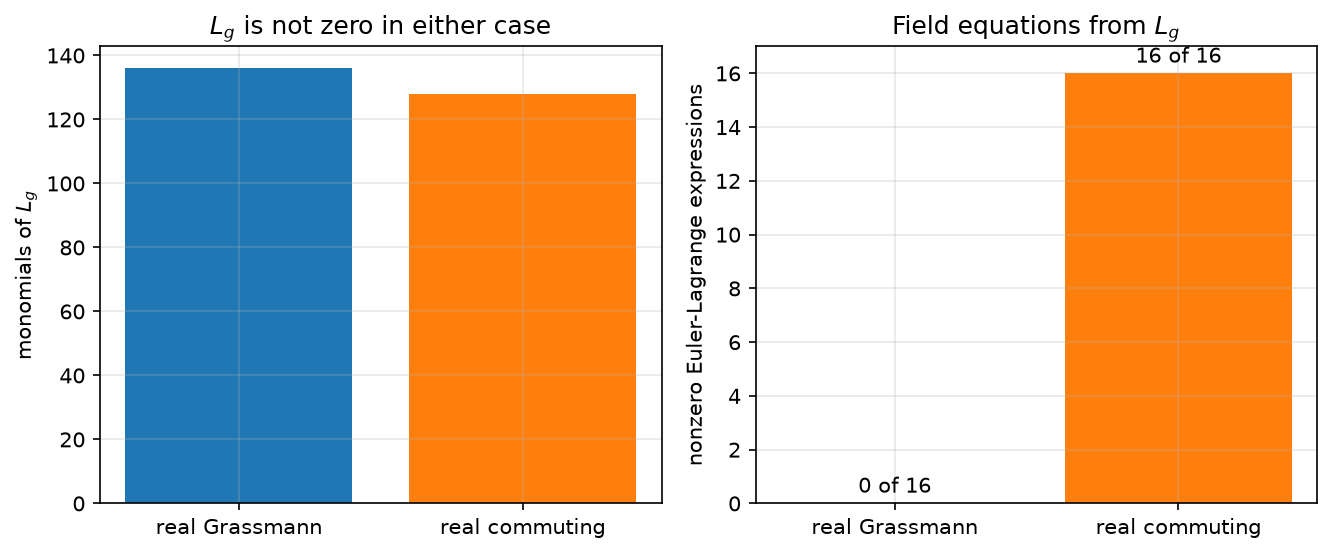

Figure 07c.1 saved as Revision/textbook/figures/07c_1_majorana_control.png


In [7]:
commuting = results["commuting"]
phi = commuting["theta"]
operator = [RealJet(False) for _ in range(16)]  # gamma^mu D_mu Phi
for mu in range(8):
    D_phi = [x + y for x, y in zip(column(False, (mu,)), matvec(Om[mu], phi, False))]
    operator = [x + y for x, y in zip(operator, matvec(gam[mu], D_phi, False))]
expected = matvec(C * 2 * sqrt_g, operator, False)  # 2 sqrt|g| C gamma^mu D_mu Phi
nonzero = sum(1 for e in commuting["EL"] if not e.is_zero())
detail = revision_check(PYREP, "negative_control_majorana_commuting_contrast")["detail"]
recorded = int(re.search(r"in (\d+) of 16 components", detail).group(1))
check(nonzero == recorded == 16, "real commuting field: Lg gives nonzero "
      "Euler-Lagrange expressions in 16 of 16 components",
      record=reproduces(PYREP, "negative_control_majorana_commuting_contrast"))
vector_zero = all(dot(vecmat(phi, C, False), matvec(G[a], phi, False), False)
                  .is_zero() for a in range(8))
check(all((e - x).is_zero() for e, x in zip(commuting["EL"], expected))
      and vector_zero, "real commuting field: the expression is 2 sqrt|g| (C "
      "gamma^mu D_mu Phi)_A and Phi^T C gamma^(a) Phi = 0",
      record=reproduces(WLREP, "Majorana_Lg_commuting_control"))

fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
labels = ["real Grassmann", "real commuting"]
left.bar(labels, [len(grassmann["Lg"].terms), len(commuting["Lg"].terms)],
         color=["tab:blue", "tab:orange"])
left.set_ylabel("monomials of $L_g$")
left.set_title("$L_g$ is not zero in either case")
counts = [sum(1 for e in grassmann["EL"] if not e.is_zero()), nonzero]
right.bar(labels, counts, color=["tab:blue", "tab:orange"])
right.set_ylim(0, 17)
right.set_ylabel("nonzero Euler-Lagrange expressions")
right.set_title("Field equations from $L_g$")
for x, value in enumerate(counts):
    right.text(x, value + 0.4, f"{value} of 16", ha="center")
fig.tight_layout()
save_figure(fig, "majorana_control",
            "The Majorana-type Lagrangian $L_g = \\sqrt{|g|}\\,\\Theta^T C\\gamma^\\mu "
            "D_\\mu\\Theta$ of the author's notebook in the author's metric, for a "
            "real column of 16 anticommuting (blue) or commuting (orange) "
            "components. Left: the number of monomials of $L_g$ in the jet algebra; "
            "it is not zero in either case. Right: the number of its 16 "
            "Euler-Lagrange expressions that are not zero. For anticommuting "
            "components $L_g$ is a total derivative and gives no field equation at "
            "all (0 of 16); for commuting components it gives a field equation in "
            "every component (16 of 16).")

## 9. Which matrices turn solutions into solutions?

We look for all $16\times16$ matrices $M$ with $M\gamma^{(a)} = s\,\gamma^{(a)}M$
for all eight $a$ (for real gammas $(\gamma^{(a)})^* = \gamma^{(a)}$, so this is the
condition of section 4). The 256 products $\gamma_I = \gamma^{(a_1)}\cdots
\gamma^{(a_k)}$ with $a_1 < \dots < a_k$ (all subsets $I$ of the eight gammas,
including the empty product 1) are a basis of all $16\times16$ matrices, because
they are mutually orthogonal: $\mathrm{tr}(\gamma_I^T\gamma_J) = 16\,\delta_{IJ}$
(the next cell checks this exactly with integers), and 256 orthogonal nonzero
matrices in the 256-dimensional space of $16\times16$ matrices form a basis.

Each basis product either commutes or anticommutes with a given $\gamma^{(a)}$:
moving $\gamma^{(a)}$ through the $k$ factors costs $(-1)^k$ if $a \notin I$ and
$(-1)^{k-1}$ if $a \in I$ (it passes $k - 1$ other factors and commutes with
itself). Write $M = \sum_I c_I\gamma_I$; since $\gamma^{(a)}\gamma_I(\gamma^{(a)})^{-1}
= \pm\gamma_I$ and the $\gamma_I$ are independent, the condition holds exactly when
every $\gamma_I$ with $c_I \ne 0$ has the sign $s$ for every $a$. So the solution
space is spanned by the products that commute with ALL eight gammas ($s = +1$) or
anticommute with ALL eight ($s = -1$). The next cell counts, for each product, the
number of gammas it commutes with, and finds which products qualify.

In [8]:
Gn = [np.array(gm.tolist(), dtype=np.int64) for gm in G]  # exact integer arrays
products, commute_counts, degrees = [], [], []
for k in range(9):
    for subset in combinations(range(8), k):
        P = np.eye(16, dtype=np.int64)
        for a in subset:
            P = P @ Gn[a]  # gamma_(a1) ... gamma_(ak)
        products.append(P)
        degrees.append(k)
        commute_counts.append(sum(1 for a in range(8)
                                  if np.array_equal(P @ Gn[a], Gn[a] @ P)))
flat = np.array([P.reshape(256) for P in products])  # one row per product
gram = flat @ flat.T  # all traces tr(gamma_I^T gamma_J), exact integers
check(len(products) == 256 and np.array_equal(gram, 16 * np.eye(256, dtype=np.int64)),
      "the 256 products of gammas are orthogonal: a basis of all 16 x 16 matrices")
same = [i for i in range(256) if commute_counts[i] == 8]  # commute with all
reversed_ = [i for i in range(256) if commute_counts[i] == 0]  # anticommute with all
report("products that commute with all 8 gammas (degree)", [degrees[i] for i in same])
report("products that anticommute with all 8 gammas (degree)",
       [degrees[i] for i in reversed_])
GAMMAn = np.array(GAMMA.tolist(), dtype=np.int64)
check(len(same) == 1 and np.array_equal(products[same[0]], np.eye(16, dtype=np.int64)),
      "s = +1: the solutions M form a 1-dimensional space, spanned by the identity",
      record=reproduces(LEAD, "intertwiners_same_mass"))
check(len(reversed_) == 1 and (np.array_equal(products[reversed_[0]], GAMMAn)
                               or np.array_equal(products[reversed_[0]], -GAMMAn)),
      "s = -1: the solutions M form a 1-dimensional space, spanned by Gamma",
      record=reproduces(LEAD, "intertwiners_reversed_mass"))

PASS the 256 products of gammas are orthogonal: a basis of all 16 x 16 matrices
RESULT products that commute with all 8 gammas (degree) = [0]
RESULT products that anticommute with all 8 gammas (degree) = [8]
PASS s = +1: the solutions M form a 1-dimensional space, spanned by the identity
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    intertwiners_same_mass
PASS s = -1: the solutions M form a 1-dimensional space, spanned by Gamma
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    intertwiners_reversed_mass


The product of all eight gammas in the order $x_1, \dots, x_8$ is $\pm\Gamma$ (the
sign depends only on the order of the factors), so the second space is spanned by
$\Gamma$. Figure 2 shows the whole pattern: for a product of $k$ gammas, the number
of gammas it commutes with is $k$ when $k$ is odd and $8 - k$ when $k$ is even. Only
the empty product ($k = 0$) commutes with all eight, and only the full product ($k
= 8$) with none.

PASS a product of k gammas commutes with k of them (k odd) or 8 - k (k even)


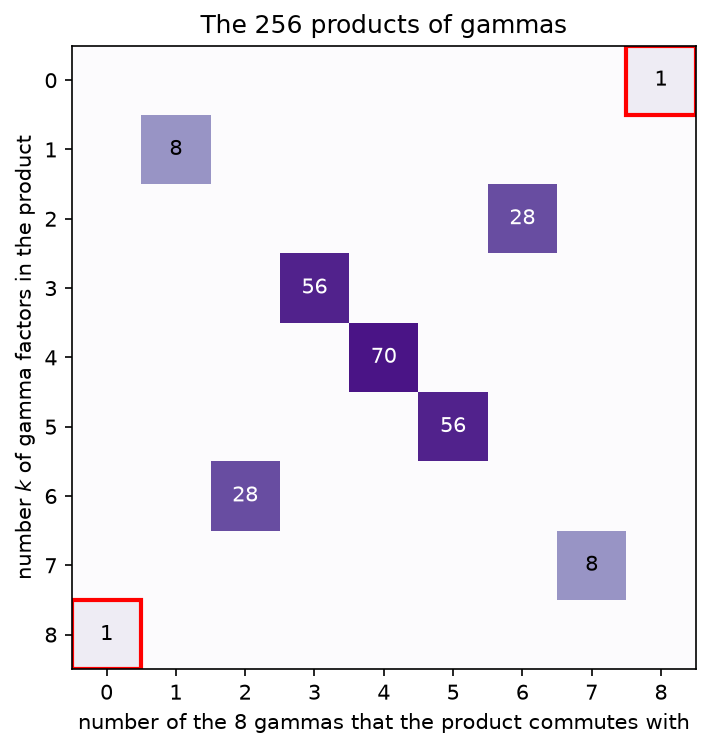

Figure 07c.2 saved as Revision/textbook/figures/07c_2_commutation_pattern.png


In [9]:
table = np.zeros((9, 9), dtype=int)  # rows: degree k, columns: number commuted with
for k, j in zip(degrees, commute_counts):
    table[k, j] += 1
binomials = [1, 8, 28, 56, 70, 56, 28, 8, 1]  # the number of products of k gammas
check(all(table[k, k if k % 2 else 8 - k] == binomials[k] for k in range(9)),
      "a product of k gammas commutes with k of them (k odd) or 8 - k (k even)")

fig, ax = plt.subplots(figsize=(6.6, 5.4))
shown = np.where(table > 0, np.log10(np.maximum(table, 1)) + 0.3, 0.0)
image = ax.imshow(shown, cmap="Purples", vmin=0, vmax=2.3)
for k in range(9):
    for j in range(9):
        if table[k, j]:
            ax.text(j, k, str(table[k, j]), ha="center", va="center",
                    color="white" if table[k, j] > 20 else "black")
ax.add_patch(plt.Rectangle((7.5, -0.5), 1, 1, fill=False, edgecolor="red",
                           linewidth=2))
ax.add_patch(plt.Rectangle((-0.5, 7.5), 1, 1, fill=False, edgecolor="red",
                           linewidth=2))
ax.set_xticks(range(9))
ax.set_yticks(range(9))
ax.set_xlabel("number of the 8 gammas that the product commutes with")
ax.set_ylabel("number $k$ of gamma factors in the product")
ax.set_title("The 256 products of gammas")
ax.grid(False)
save_figure(fig, "commutation_pattern",
            "The 256 products $\\gamma_I$ of the author's gamma matrices (a basis "
            "of all $16 \\times 16$ matrices), counted by the number $k$ of factors "
            "(rows) and by the number of the eight gammas with which they commute "
            "(columns); the numbers are the binomial coefficients. Only two squares "
            "(red frames) lie in the outer columns: the identity ($k = 0$) commutes "
            "with all eight, and the chirality matrix $\\Gamma$ ($k = 8$) "
            "anticommutes with all eight. Hence every matrix $M$ with $M\\gamma^{(a)} "
            "= \\pm\\gamma^{(a)}M$ for all $a$ is a multiple of 1 or of $\\Gamma$.")

## 10. The two charge-conjugation matrices

With $M = \mathcal{C}C$ and $C^{-1} = C$: $\mathcal{C}_+ = C$ (from $M = 1$) and
$\mathcal{C}_- = \Gamma C$ (from $M = \Gamma$). The defining properties of a
charge-conjugation matrix, $\mathcal{C}^{-1}\gamma^{(a)}\mathcal{C} =
\mp(\gamma^{(a)})^T$, follow line by line for $\mathcal{C}_+ = C$:

$$C^{-1}\gamma^{(a)}C = (C\gamma^{(a)})\,C = -(C\gamma^{(a)})^T C
= -(\gamma^{(a)})^T C^T C = -(\gamma^{(a)})^T .$$

The first step uses $C^{-1} = C$ (because $C^2 = 1$); the second that
$C\gamma^{(a)}$ is antisymmetric; the third that the transpose of a product is the
product of the transposes in reversed order; the last that $C^TC = C^2 = 1$. For
$\mathcal{C}_- = \Gamma C$: $\mathcal{C}_-^{-1} = C\Gamma$, and $\Gamma\gamma^{(a)}
\Gamma = -\gamma^{(a)}$ (anticommute, then $\Gamma^2 = 1$), so
$\mathcal{C}_-^{-1}\gamma^{(a)}\mathcal{C}_- = -C\gamma^{(a)}C =
+(\gamma^{(a)})^T$. Both matrices are real, and both reality conditions $\Psi =
M\Psi^*$ are consistent because $MM^* = 1$ for $M = 1$ and for $M = \Gamma$
($\Gamma$ is real and $\Gamma^2 = 1$). The next cell checks all of this exactly.

In [10]:
C_plus, C_minus = C, GAMMA * C
check(all(C_plus.inv() * g * C_plus == -g.T for g in G) and C_plus.T == C_plus,
      "calC_+ = C: calC_+^-1 gamma^a calC_+ = -(gamma^a)^T, real symmetric",
      record=reproduces(LEAD, "charge_conjugation_matrix_plus"))
check(all(C_minus.inv() * g * C_minus == g.T for g in G)
      and all(v.is_real for v in C_minus),
      "calC_- = Gamma C: calC_-^-1 gamma^a calC_- = +(gamma^a)^T, real",
      record=reproduces(LEAD, "charge_conjugation_matrix_minus"))
check(I16 * I16.conjugate() == I16 and GAMMA * GAMMA.conjugate() == I16,
      "M M* = 1 for M = 1 and M = Gamma: both reality conditions are consistent",
      record=reproduces(LEAD, "majorana_conditions_consistent"))

PASS calC_+ = C: calC_+^-1 gamma^a calC_+ = -(gamma^a)^T, real symmetric
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    charge_conjugation_matrix_plus
PASS calC_- = Gamma C: calC_-^-1 gamma^a calC_- = +(gamma^a)^T, real
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    charge_conjugation_matrix_minus
PASS M M* = 1 for M = 1 and M = Gamma: both reality conditions are consistent
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    majorana_conditions_consistent


## 11. Real fields: what charge conjugation does to them

For a real column $\Phi$ ($\Phi^* = \Phi$, so $\Phi^\dagger = \Phi^T$):

$$\Phi^c_+ = \mathcal{C}_+\bar\Phi^T = C\,(\Phi^T C)^T = C\,C^T\Phi = \Phi,
\qquad \Phi^c_- = \mathcal{C}_-\bar\Phi^T = \Gamma C\,C\Phi = \Gamma\Phi .$$

So $\mathcal{C}_+$ does nothing to a real field: a real field is its own
conjugate. This matches the current: $J^a = -i\Phi^T C\gamma^{(a)}\Phi = 0$
identically, because $C\gamma^{(a)}$ is antisymmetric and the components commute; a
real commuting field carries no charge. The only nontrivial real map is the matrix
$\Gamma$. It keeps the scalar density and reverses every kinetic matrix:

$$\Gamma^T C\Gamma = C,\qquad \Gamma^T C\gamma^{(a)}\Gamma = -C\gamma^{(a)} .$$

(Both from $\Gamma^T = \Gamma$, which commutes with $C$, and anticommutes with
$\gamma^{(a)}$.) Therefore, for real fields, $L_{m,\lambda}[\Gamma\Phi] =
-L_{-m,-\lambda}[\Phi]$: the matrix $\Gamma$ together with $(m, \lambda) \to (-m,
-\lambda)$ maps solutions to solutions. The next cell checks the two conjugates,
the vanishing current and the two matrix identities, and draws Figure 3.

PASS for a real field Phi: calC_+ gives Phi itself, calC_- gives Gamma Phi
PASS real commuting field: J^a = 0 for every a; Gamma^T C Gamma = C and Gamma^T C gamma^a
    Gamma = -C gamma^a
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    real_fields_charge_conjugation


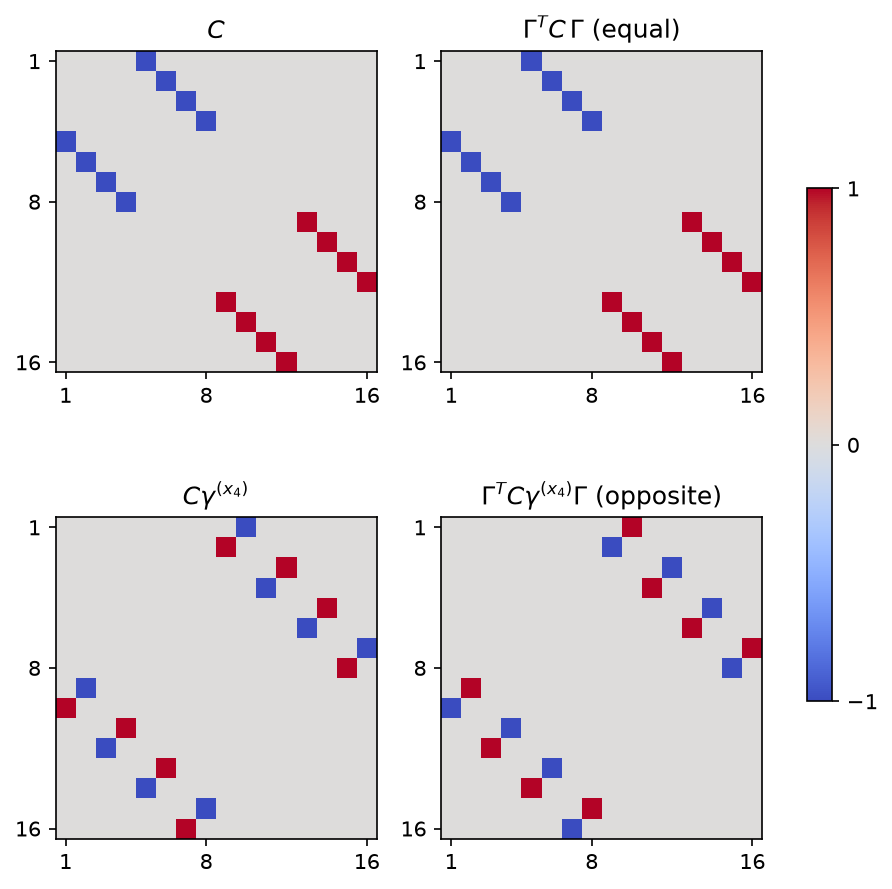

Figure 07c.3 saved as Revision/textbook/figures/07c_3_gamma_map_matrices.png


In [11]:
phi_bar_T = (r.T * C).T  # (Phi^T C)^T for the real column r
check((C_plus * phi_bar_T - r).applyfunc(sp.expand) == sp.zeros(16, 1)
      and (C_minus * phi_bar_T - GAMMA * r).applyfunc(sp.expand) == sp.zeros(16, 1),
      "for a real field Phi: calC_+ gives Phi itself, calC_- gives Gamma Phi")
currents = [sp.expand((-sp.I * r.T * C * g * r)[0, 0]) for g in G]
kinetic_reversed = all(GAMMA.T * C * g * GAMMA == -(C * g) for g in G)
check(all(j == 0 for j in currents) and GAMMA.T * C * GAMMA == C and kinetic_reversed,
      "real commuting field: J^a = 0 for every a; Gamma^T C Gamma = C and Gamma^T C "
      "gamma^a Gamma = -C gamma^a",
      record=reproduces(LEAD, "real_fields_charge_conjugation"))

numbers = [np.array(M.tolist(), dtype=float) for M in
           (C, GAMMA.T * C * GAMMA, C * G[X4], GAMMA.T * C * G[X4] * GAMMA)]
titles = ["$C$", "$\\Gamma^T C\\,\\Gamma$ (equal)", "$C\\gamma^{(x_4)}$",
          "$\\Gamma^T C\\gamma^{(x_4)}\\Gamma$ (opposite)"]
fig, axes = plt.subplots(2, 2, figsize=(7.6, 7.4))
for ax, M, title in zip(axes.flat, numbers, titles):
    image = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks([0, 7, 15], ["1", "8", "16"])
    ax.set_yticks([0, 7, 15], ["1", "8", "16"])
    ax.grid(False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.6)
save_figure(fig, "gamma_map_matrices",
            "What the real matrix $\\Gamma$ does to the two kinds of terms of the "
            "Lagrangian of a real field ($16 \\times 16$ matrices, red $+1$, blue "
            "$-1$, grey 0; rows and columns 1 to 16). Top: the matrix $C$ of the "
            "scalar density $S = \\Phi^T C\\Phi$ and $\\Gamma^T C\\Gamma$, which is "
            "the same: $S$ is kept. Bottom: the kinetic matrix $C\\gamma^{(x_4)}$ "
            "and $\\Gamma^T C\\gamma^{(x_4)}\\Gamma$, which has every colour "
            "swapped: the kinetic term changes sign (the same holds for all eight "
            "directions). So the Lagrangian of $\\Gamma\\Phi$ with $(m, \\lambda)$ "
            "is minus the Lagrangian of $\\Phi$ with $(-m, -\\lambda)$.")

## 12. The mass reversal in the author's metric

The next cell checks the statement $L_{m,\lambda}[\Gamma\Phi] =
-L_{-m,-\lambda}[\Phi]$ for a real commuting field in the author's metric, exactly,
with the jet algebra. The Lagrangian of a real field is the Revision Lagrangian with
$\Psi^\dagger = \Phi^T$: $\bar\Phi = \Phi^T C$, $D_\mu\bar\Phi = \partial_\mu
\Phi^T C - \Phi^T C\Omega_\mu$. The field $\Gamma\Phi$ has the components
$\sum_B\Gamma_{AB}\theta_B$ and the derivatives $\sum_B\Gamma_{AB}\partial_\mu
\theta_B$ ($\Gamma$ is constant). The cell also checks that the Euler-Lagrange
expressions of the real Lagrangian are $2\sqrt{|g|}\,(C(\gamma^\mu D_\mu\Phi - (m +
\lambda S)\Phi))_A$: a real commuting field obeys the same field equation as the
complex one.

In [12]:
def real_lagrangian(columns, mass, coupling):
    """sqrt|g| [K - mass S - (coupling/2) S^2] of the real field whose value and
    derivatives are columns(derivatives)."""
    field = columns(())
    bar = vecmat(field, C, False)  # Phi^T C
    K = RealJet(False)
    for mu in range(8):
        D_field = [x + y for x, y in zip(columns((mu,)), matvec(Om[mu], field, False))]
        D_bar = [x - y for x, y in zip(vecmat(columns((mu,)), C, False),
                                       vecmat(bar, Om[mu], False))]
        K = K + dot(bar, matvec(gam[mu], D_field, False), False)
        K = K - dot(vecmat(D_bar, gam[mu], False), field, False)
    S = dot(bar, field, False)
    return (K.times(sp.Rational(1, 2)) - S.times(mass)
            - (S * S).times(coupling / 2)).times(sqrt_g)


def plain(derivatives):  # the components of Phi
    return column(False, derivatives)


def mapped(derivatives):  # the components of Gamma Phi
    return matvec(GAMMA, column(False, derivatives), False)


L_mapped = real_lagrangian(mapped, m, lam)
L_reversed = real_lagrangian(plain, -m, -lam)
check((L_mapped + L_reversed).is_zero(), "real field in the author's metric: "
      "L_(m, lambda)[Gamma Phi] = -L_(-m, -lambda)[Phi]")
L_real = real_lagrangian(plain, m, lam)
S_real = dot(vecmat(phi, C, False), phi, False)
residual = [x - (RealJet(False, {(): m}) + S_real.times(lam)) * y
            for x, y in zip(operator, phi)]  # gamma D Phi - (m + lambda S) Phi
target = matvec(C * 2 * sqrt_g, residual, False)
ok = True
for A in range(16):
    value = L_real.lderiv((A, ()))
    for mu in range(8):
        value = value - L_real.lderiv((A, (mu,))).total(mu)
    ok = ok and (value - target[A]).is_zero()
check(ok, "real commuting field: Euler-Lagrange expressions 2 sqrt|g| (C (gamma^mu "
      "D_mu Phi - (m + lambda S) Phi))_A")

PASS real field in the author's metric: L_(m, lambda)[Gamma Phi] = -L_(-m, -lambda)[Phi]
PASS real commuting field: Euler-Lagrange expressions 2 sqrt|g| (C (gamma^mu D_mu Phi -
    (m + lambda S) Phi))_A


**A real solution and its image.** Notebook 07b verified the exact family $\Psi =
\sin^\alpha z\,(\cosh kx_4 + \sinh(kx_4)/k\,M)\chi_0$ with $M = -m\gamma^{(x_4)} +
3H(2\alpha + 1)\gamma^{(x_4)}\gamma^{(x_8)}$. For a real $\chi_0$ and real $k$ it is
a real solution. Because $\Gamma$ anticommutes with $\gamma^{(x_4)}$ and commutes
with $\gamma^{(x_4)}\gamma^{(x_8)}$, $\Gamma M_m\Gamma = M_{-m}$: the image $\Gamma
\Psi$ is the member of the family with mass $-m$ and the column $\Gamma\chi_0$. The
next cell checks $\Gamma M_m\Gamma = M_{-m}$ exactly, then evaluates, for the
illustration values $H = 1$, $m = 2$, $\alpha = 0$ ($k = \sqrt5$), $\chi_0 = e_1 +
2e_{13}$, $z = \pi/4$ and $x_4$ from 0 to 2, the residuals
$\gamma^{(x_4)}\partial_4\Psi + 3H\gamma^{(x_8)}\Psi - \mu\Psi$ of $\Phi$ and of
$\Gamma\Phi$ in the equations with $\mu = +m$ and $\mu = -m$ (Figure 4).

In [13]:
mass_symbol = sp.Symbol("mu", real=True)


def M_of(mass):
    return -mass * G[X4] + 3 * H * G[X4] * G[X8]  # alpha = 0


check((GAMMA * M_of(mass_symbol) * GAMMA - M_of(-mass_symbol)).applyfunc(sp.expand)
      == Z16, "Gamma M_m Gamma = M_(-m): Gamma maps the family of mass m to mass -m")

Gf = [np.array(gm.tolist(), dtype=float) for gm in G]
GAMMAf = np.array(GAMMA.tolist(), dtype=float)
chi0 = np.zeros(16)
chi0[0], chi0[12] = 1.0, 2.0  # e_1 + 2 e_13: one component in each chiral half
times = np.linspace(0.0, 2.0, 201)
Mf = -2.0 * Gf[X4] + 3.0 * Gf[X4] @ Gf[X8]  # m = 2, H = 1
kk = np.sqrt(5.0)
Phi = np.array([(np.cosh(kk * t) * np.eye(16) + np.sinh(kk * t) / kk * Mf) @ chi0
                for t in times])
dPhi = np.array([(kk * np.sinh(kk * t) * np.eye(16) + np.cosh(kk * t) * Mf) @ chi0
                 for t in times])


def residual_size(values, derivatives, mass):
    """The largest component of gamma4 d4 Psi + 3 gamma8 Psi - mass Psi."""
    return np.array([np.abs(Gf[X4] @ d + 3.0 * Gf[X8] @ v - mass * v).max()
                     for v, d in zip(values, derivatives)])


image_values, image_derivatives = Phi @ GAMMAf.T, dPhi @ GAMMAf.T  # Gamma Phi
size = np.abs(Phi).max(axis=1)
phi_plus = residual_size(Phi, dPhi, 2.0) / size
image_minus = residual_size(image_values, image_derivatives, -2.0) / size
image_plus = residual_size(image_values, image_derivatives, 2.0)
check(phi_plus.max() < 1e-12 and image_minus.max() < 1e-12
      and np.allclose(image_plus, 4.0 * size),
      "numerically: Phi solves the mass +2 equation, Gamma Phi the mass -2 equation "
      "(relative residuals below 1e-12); Gamma Phi fails the +2 equation by 2 m |Phi|")

PASS Gamma M_m Gamma = M_(-m): Gamma maps the family of mass m to mass -m
PASS numerically: Phi solves the mass +2 equation, Gamma Phi the mass -2 equation
    (relative residuals below 1e-12); Gamma Phi fails the +2 equation by 2 m |Phi|


Figure 4: left, two components of $\Phi$ and of $\Gamma\Phi$ ($\Gamma =
\mathrm{diag}(-1, \dots, -1, 1, \dots, 1)$ flips the sign of components 1 to 8 and
keeps 9 to 16); right, the residuals of the image in the wrong and in the right
equation.

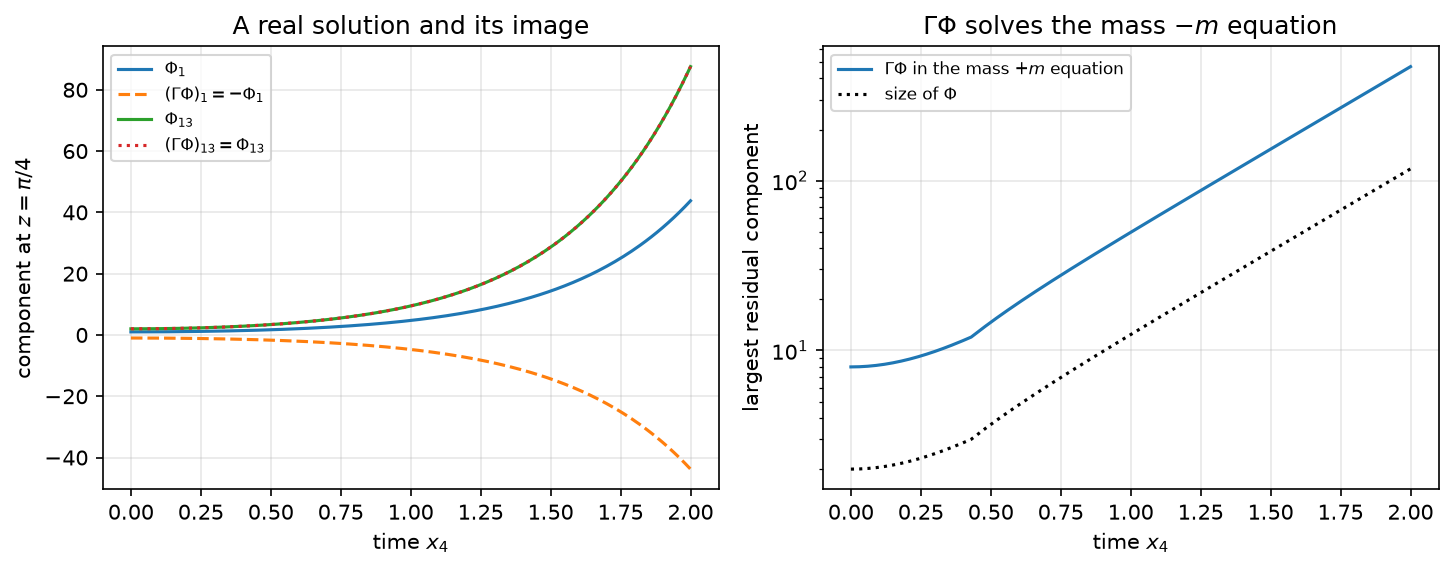

Figure 07c.4 saved as Revision/textbook/figures/07c_4_mass_reversal.png


In [14]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.9))
left.plot(times, Phi[:, 0], label="$\\Phi_1$")
left.plot(times, image_values[:, 0], "--", label="$(\\Gamma\\Phi)_1 = -\\Phi_1$")
left.plot(times, Phi[:, 12], label="$\\Phi_{13}$")
left.plot(times, image_values[:, 12], ":", label="$(\\Gamma\\Phi)_{13} = \\Phi_{13}$")
left.set_xlabel("time $x_4$")
left.set_ylabel("component at $z = \\pi/4$")
left.set_title("A real solution and its image")
left.legend(fontsize=8)
right.semilogy(times, image_plus, label="$\\Gamma\\Phi$ in the mass $+m$ equation")
right.semilogy(times, size, ":", color="black", label="size of $\\Phi$")
right.set_xlabel("time $x_4$")
right.set_ylabel("largest residual component")
right.set_title("$\\Gamma\\Phi$ solves the mass $-m$ equation")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "mass_reversal",
            "The real matrix $\\Gamma$ reverses the mass. Left: components 1 and 13 "
            "of the real exact solution $\\Phi$ (illustration values $H = 1$, "
            "$m = 2$, $\\alpha = 0$, $\\chi_0 = e_1 + 2e_{13}$, at $z = \\pi/4$) and "
            "of its image $\\Gamma\\Phi$ against the time $x_4$: $\\Gamma$ reverses "
            "the sign of the components 1 to 8 and keeps 9 to 16. Right "
            "(logarithmic axis): the largest component of the residual of "
            "$\\Gamma\\Phi$ in the equation with mass $+m$ (solid), which is $2m$ "
            "times the size of $\\Phi$ (dotted); in the equation with mass $-m$ the "
            "residual is zero up to rounding (below $10^{-12}$ of the size, not "
            "drawn). A real field has no charge; $\\Gamma$ relates solutions of "
            "masses $m$ and $-m$.")

## 13. The last check

The last cell checks that the four figure files exist and prints the number of
checks that passed.

In [15]:
names = ["majorana_control", "commutation_pattern", "gamma_map_matrices",
         "mass_reversal"]
files = [f"{FIGURE_FOLDER}/07c_{k}_{name}.png" for k, name in enumerate(names, 1)]
check(all(output_file(path).is_file() for path in files),
      "all 4 figure files of this notebook exist")
all_checks_passed()

PASS all 4 figure files of this notebook exist
ALL 23 CHECKS PASSED (notebook 07c)


## 14. What this notebook showed

- The Majorana-type Lagrangian $L_g = \sqrt{|g|}\,\Theta^T C\gamma^\mu D_\mu\Theta$
  of the author's notebook is, for a real anticommuting 16-component field in the
  author's metric, exactly the total derivative of $\frac12\sqrt{|g|}\,\Theta^T
  C\gamma^\mu\Theta$: no field equation; its mass term $\Theta^T C\Theta$ vanishes.
  For real commuting components it gives a field equation in all 16 components.
  This negative control is why the Revision Lagrangian uses the complex field with
  $\bar\Psi = \Psi^\dagger C$.
- The author's gammas, $C$, $\Gamma$ and the spin connection are real; the field
  equation is real; real fields are a consistent restriction, and the real
  Lagrangian gives $\gamma^\mu D_\mu\Phi = (m + \lambda S)\Phi$.
- Charge conjugation is a MATRIX map. Every matrix $M$ with $M\gamma^{(a)} =
  s\gamma^{(a)}M$ for all $a$ is a multiple of 1 ($s = +1$) or of $\Gamma$ ($s =
  -1$), because among the 256 products of gammas only the identity commutes and
  only $\Gamma$ anticommutes with all eight. The two charge-conjugation matrices are
  $\mathcal{C}_+ = C$ (same mass, $\Psi^c = \Psi^*$) and $\mathcal{C}_- = \Gamma C$
  (mass reversed, $\Psi^c = \Gamma\Psi^*$); both reality conditions are consistent.
- For a REAL field plain complex conjugation is the identity, and so is
  $\mathcal{C}_+$: a real field is its own conjugate and its current $J^a$ vanishes.
  The nontrivial real map is the matrix $\Gamma$ with $(m, \lambda) \to (-m,
  -\lambda)$: $L_{m,\lambda}[\Gamma\Phi] = -L_{-m,-\lambda}[\Phi]$, and $\Gamma$ maps
  the real solutions of mass $m$ onto real solutions of mass $-m$.
- These are exact maps between solutions of two equations (PROVED, with the checks
  named above). They do not say that such solutions are created, in pairs or
  otherwise.